# EDA Analysis — Bluestock Fintech Mutual Fund Capstone
### Day 3 — Exploratory Data Analysis
**15+ Charts | NAV Trends · AUM · SIP · Demographics · Sector Exposure**

All data sourced from AMFI India, mfapi.in, NSE/BSE public records.

## 0. Setup — Imports & Paths

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#  Paths
BASE_DIR  = Path().resolve().parent          # project root
PROC_DIR  = BASE_DIR / 'data' / 'processed'
CHART_DIR = BASE_DIR / 'reports' / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

#  Style 
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
COLORS = px.colors.qualitative.Set2

print(' Imports done. Chart output folder:', CHART_DIR)

✅ Imports done. Chart output folder: C:\Users\LENOVO\OneDrive\Desktop\bluestock-mf-capstone\reports\charts


## 1. Load All Cleaned Datasets

In [4]:
nav    = pd.read_csv(PROC_DIR / 'clean_nav.csv',               parse_dates=['date'])
fm     = pd.read_csv(PROC_DIR / 'clean_fund_master.csv')
aum    = pd.read_csv(PROC_DIR / 'clean_aum_by_fund_house.csv', parse_dates=['date'])
sip    = pd.read_csv(PROC_DIR / 'clean_monthly_sip_inflows.csv', parse_dates=['month'])
cat    = pd.read_csv(PROC_DIR / 'clean_category_inflows.csv',  parse_dates=['month'])
txn    = pd.read_csv(PROC_DIR / 'clean_transactions.csv',      parse_dates=['transaction_date'])
folio  = pd.read_csv(PROC_DIR / 'clean_industry_folio_count.csv', parse_dates=['month'])
port   = pd.read_csv(PROC_DIR / 'clean_portfolio_holdings.csv')

# Merge nav with fund master to get scheme names
nav = nav.merge(fm[['amfi_code','scheme_name','fund_house','category','sub_category']], on='amfi_code', how='left')

print(f'NAV records    : {len(nav):,}')
print(f'AUM records    : {len(aum):,}')
print(f'SIP months     : {len(sip)}')
print(f'Transactions   : {len(txn):,}')
print(f'Folio records  : {len(folio)}')
print(f'Port holdings  : {len(port)}')
print(f'Schemes        : {nav["amfi_code"].nunique()}')

NAV records    : 64,320
AUM records    : 90
SIP months     : 48
Transactions   : 32,778
Folio records  : 21
Port holdings  : 322
Schemes        : 40


## Chart 1 — NAV Trend Lines (All 40 Schemes, 2022–2026)
Plotly interactive line chart. Each line = one fund. Equity funds shown in colour, Debt in grey.

In [ ]:
# Keep only trading days (Mon–Fri) to avoid flat weekend lines
nav_trade = nav[nav['date'].dt.weekday < 5].copy()

# Separate equity and debt
nav_eq   = nav_trade[nav_trade['category'] == 'Equity']
nav_debt = nav_trade[nav_trade['category'] == 'Debt']

fig = go.Figure()

# Debt funds — grey, thin
for code, grp in nav_debt.groupby('amfi_code'):
    name = grp['scheme_name'].iloc[0].replace(' - Growth','').replace(' Plan','')
    fig.add_trace(go.Scatter(
        x=grp['date'], y=grp['nav'],
        name=name, mode='lines',
        line=dict(color='lightgrey', width=1),
        legendgroup='Debt', showlegend=False,
        hovertemplate='%{fullData.name}<br>Date: %{x|%d %b %Y}<br>NAV: ₹%{y:.2f}<extra></extra>'
    ))

# Equity funds — coloured
eq_palette = px.colors.qualitative.Plotly
for i, (code, grp) in enumerate(nav_eq.groupby('amfi_code')):
    name = grp['scheme_name'].iloc[0].replace(' - Growth','').replace(' Plan','')
    fig.add_trace(go.Scatter(
        x=grp['date'], y=grp['nav'],
        name=name, mode='lines',
        line=dict(width=1.5, color=eq_palette[i % len(eq_palette)]),
        legendgroup='Equity',
        hovertemplate='%{fullData.name}<br>Date: %{x|%d %b %Y}<br>NAV: ₹%{y:.2f}<extra></extra>'
    ))

# Annotation — 2023 Bull Run
fig.add_vrect(x0='2023-01-01', x1='2023-12-31',
              fillcolor='lightgreen', opacity=0.08,
              annotation_text='2023 Bull Run', annotation_position='top left')

# Annotation — 2024 Correction
fig.add_vrect(x0='2024-09-01', x1='2024-12-31',
              fillcolor='salmon', opacity=0.08,
              annotation_text='2024 Correction', annotation_position='top left')

fig.update_layout(
    title='NAV Trend — All 40 Schemes (Jan 2022 – May 2026)',
    xaxis_title='Date', yaxis_title='NAV (₹)',
    height=550, template='plotly_white',
    legend=dict(font_size=9, orientation='v'),
    hovermode='x unified'
)
fig.write_image(str(CHART_DIR / 'chart_01_nav_trends.png'), width=1200, height=550)
fig.show()
print(' Chart 1 saved')

✅ Chart 1 saved


## Chart 2 — AUM Growth by Fund House (2022–2025)
Grouped bar chart. SBI dominates at ₹12.5L Cr by Dec 2025.

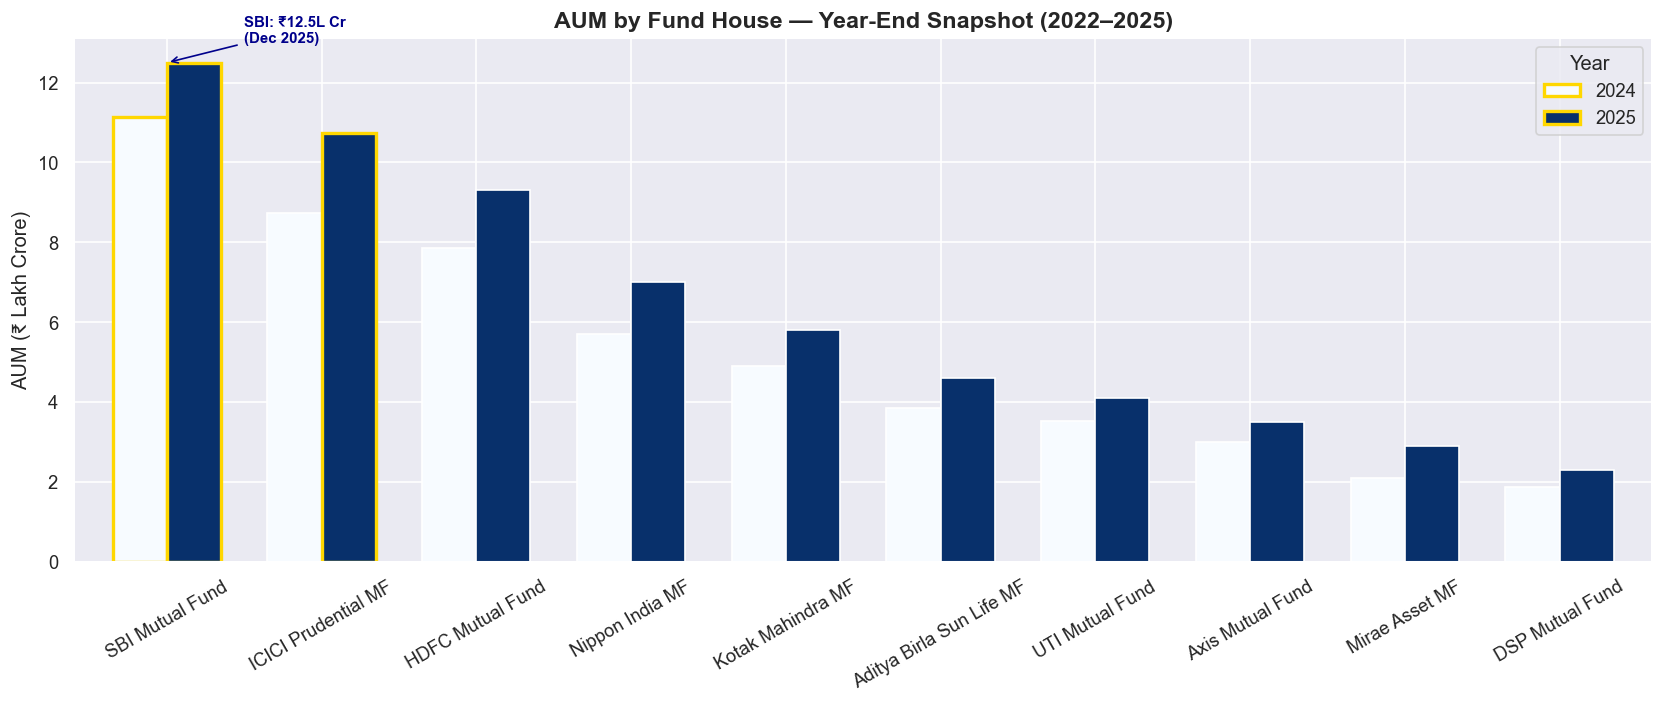

✅ Chart 2 saved


In [ ]:
aum['year'] = aum['date'].dt.year
# Keep year-end (Dec) snapshot per fund house
aum_ye = aum[aum['date'].dt.month == 12].copy()
# If Dec not available for all years, take max date per year
if len(aum_ye) == 0:
    aum_ye = aum.groupby(['year','fund_house']).last().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
aum_pivot = aum_ye.pivot_table(index='fund_house', columns='year', values='aum_lakh_crore')
aum_pivot_sorted = aum_pivot.sort_values(aum_pivot.columns[-1], ascending=False)

bars = aum_pivot_sorted.plot(
    kind='bar', ax=ax, colormap='Blues',
    width=0.7, edgecolor='white'
)

# Highlight SBI bar
for patch in ax.patches:
    if patch.get_height() > 10:
        patch.set_edgecolor('gold')
        patch.set_linewidth(2)

ax.set_title('AUM by Fund House — Year-End Snapshot (2022–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('AUM (₹ Lakh Crore)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Year', loc='upper right')
ax.annotate('SBI: ₹12.5L Cr\n(Dec 2025)',
            xy=(0, aum_pivot_sorted.iloc[0,-1]),
            xytext=(0.5, aum_pivot_sorted.iloc[0,-1] + 0.5),
            fontsize=9, color='darkblue', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkblue'))
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart_02_aum_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 2 saved')

## Chart 3 — Monthly SIP Inflow Timeline (Jan 2022 – Dec 2025)
Annotated Plotly line. ₹31,002 Cr milestone marked.

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sip['month'], y=sip['sip_inflow_crore'],
    fill='tozeroy', fillcolor='rgba(0,128,200,0.15)',
    line=dict(color='steelblue', width=2.5),
    name='SIP Inflow (₹ Cr)',
    hovertemplate='%{x|%b %Y}: ₹%{y:,.0f} Cr<extra></extra>'
))

# Annotate all-time high Dec 2025
max_row = sip.loc[sip['sip_inflow_crore'].idxmax()]
fig.add_annotation(
    x=max_row['month'].strftime('%Y-%m-%d'), y=max_row['sip_inflow_crore'],
    text=f"🏆 All-Time High<br>₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True, arrowhead=2, arrowcolor='red',
    font=dict(size=11, color='red'), bgcolor='lightyellow',
    bordercolor='red', borderwidth=1
)

# Add ₹20,000 Cr milestone line
fig.add_hline(y=20000, line_dash='dot', line_color='orange',
              annotation_text='₹20,000 Cr mark', annotation_position='top right')

fig.update_layout(
    title='Monthly SIP Inflows — Jan 2022 to Dec 2025 (Industry)',
    xaxis_title='Month', yaxis_title='SIP Inflow (₹ Crore)',
    height=420, template='plotly_white'
)
fig.write_image(str(CHART_DIR / 'chart_03_sip_inflow.png'), width=1200, height=420)
fig.show()
print(' Chart 3 saved')

✅ Chart 3 saved


## Chart 4 — Category Inflow Heatmap (Month × Category)
Red = net outflow, Green = net inflow.

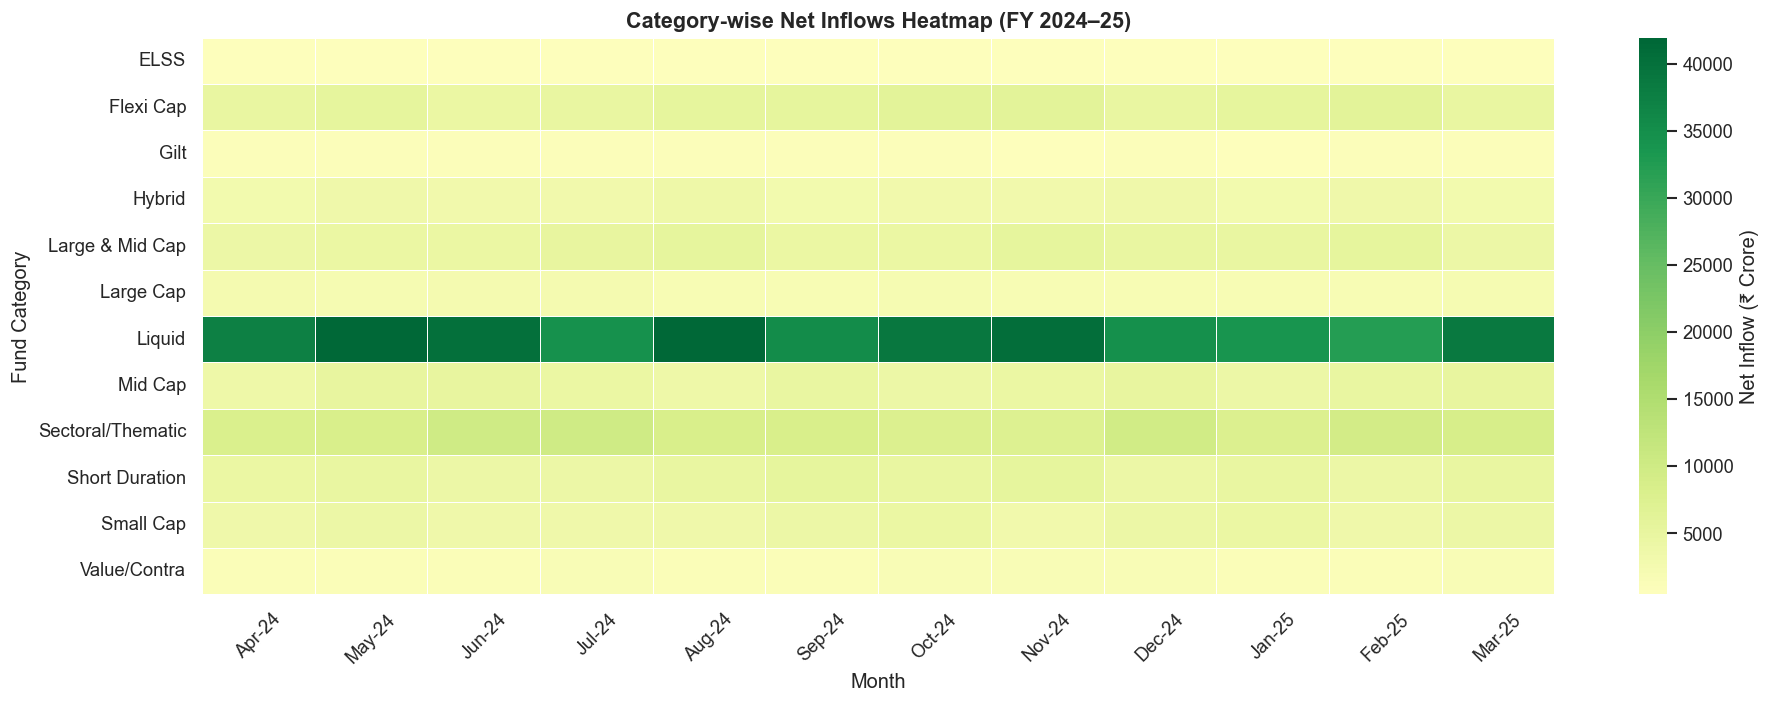

 Chart 4 saved


In [8]:
cat['month_label'] = cat['month'].dt.strftime('%b-%y')
cat_pivot = cat.pivot_table(index='category', columns='month_label', values='net_inflow_crore')

# Keep month order correct
month_order = cat.sort_values('month')['month_label'].unique().tolist()
cat_pivot = cat_pivot.reindex(columns=month_order)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    cat_pivot, cmap='RdYlGn', center=0,
    linewidths=0.3, linecolor='white',
    fmt='.0f', annot=False,
    cbar_kws={'label': 'Net Inflow (₹ Crore)'},
    ax=ax
)
ax.set_title('Category-wise Net Inflows Heatmap (FY 2024–25)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Fund Category')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart_04_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 4 saved')

## Charts 5 & 6 — Investor Demographics
Age group pie chart, SIP box plot by age, gender split.

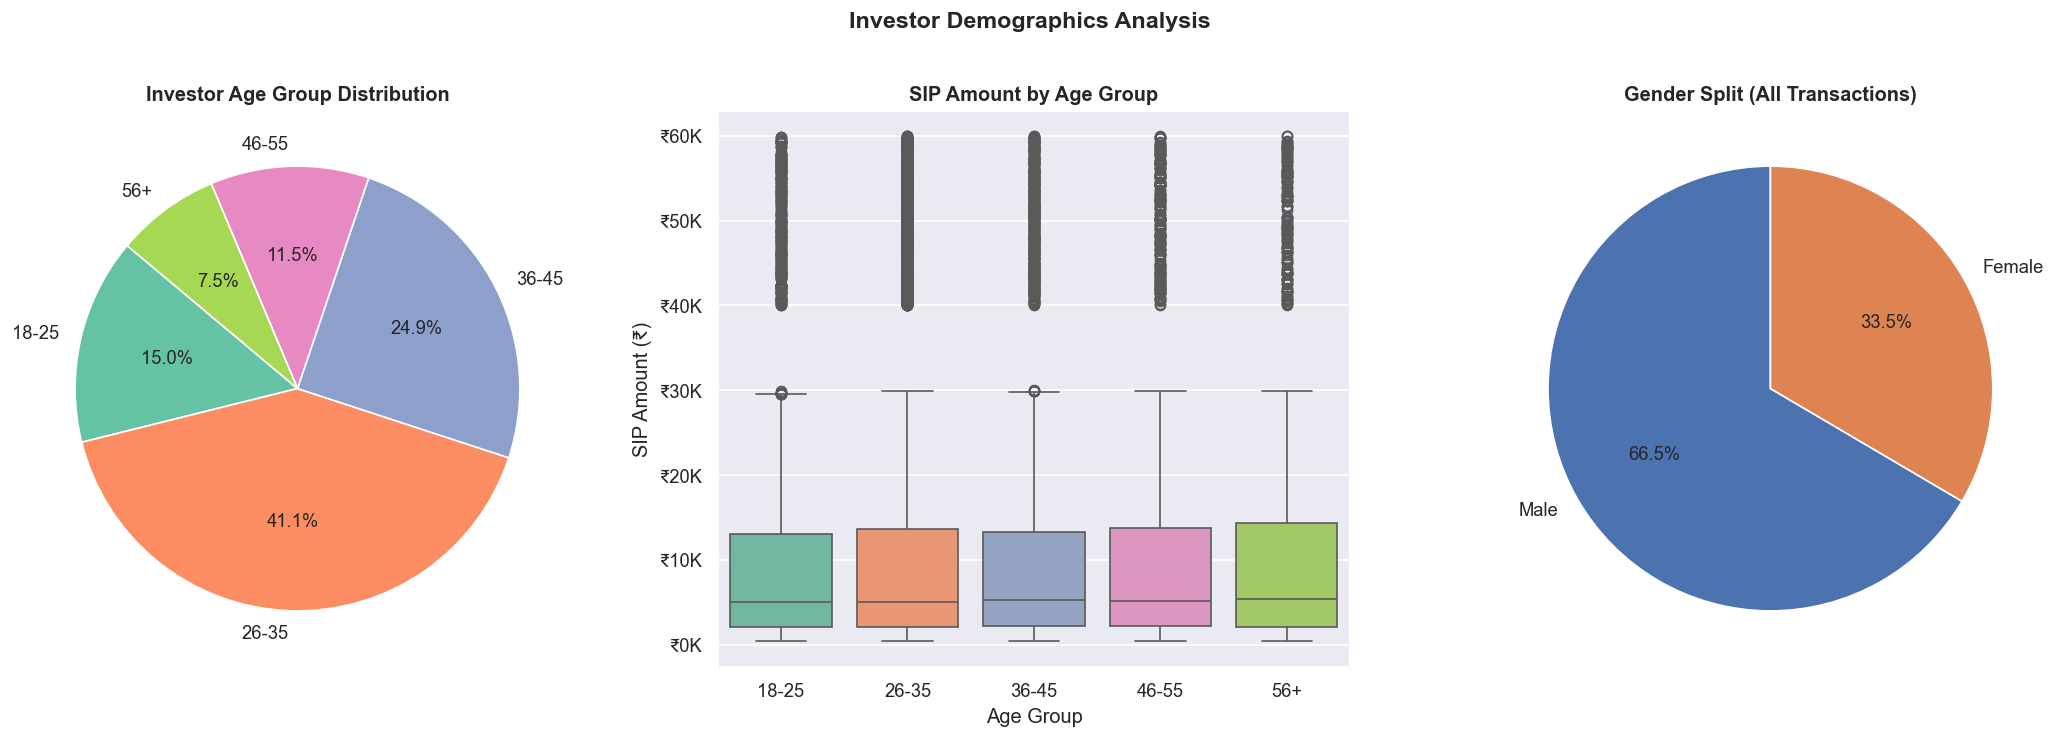

✅ Charts 5a/5b/5c saved


In [ ]:
sip_txn = txn[txn['transaction_type'] == 'SIP'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#  Chart 5a: Age group pie 
age_counts = txn['age_group'].value_counts().sort_index()
age_order  = ['18-25','26-35','36-45','46-55','56+']
age_counts = age_counts.reindex(age_order)
axes[0].pie(
    age_counts.values,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(age_counts))
)
axes[0].set_title('Investor Age Group Distribution', fontweight='bold')

#  Chart 5b: SIP amount box plot by age 
sns.boxplot(
    data=sip_txn,
    x='age_group', y='amount_inr',
    order=age_order,
    palette='Set2', ax=axes[1]
)
axes[1].set_title('SIP Amount by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

#  Chart 5c: Gender split pie 
gender_counts = txn['gender'].value_counts()
axes[2].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0','#DD8452']
)
axes[2].set_title('Gender Split (All Transactions)', fontweight='bold')

plt.suptitle('Investor Demographics Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart_05_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Charts 5a/5b/5c saved')

## Chart 6 — Geographic Distribution
SIP amount by state (horizontal bar) + T30 vs B30 pie chart.

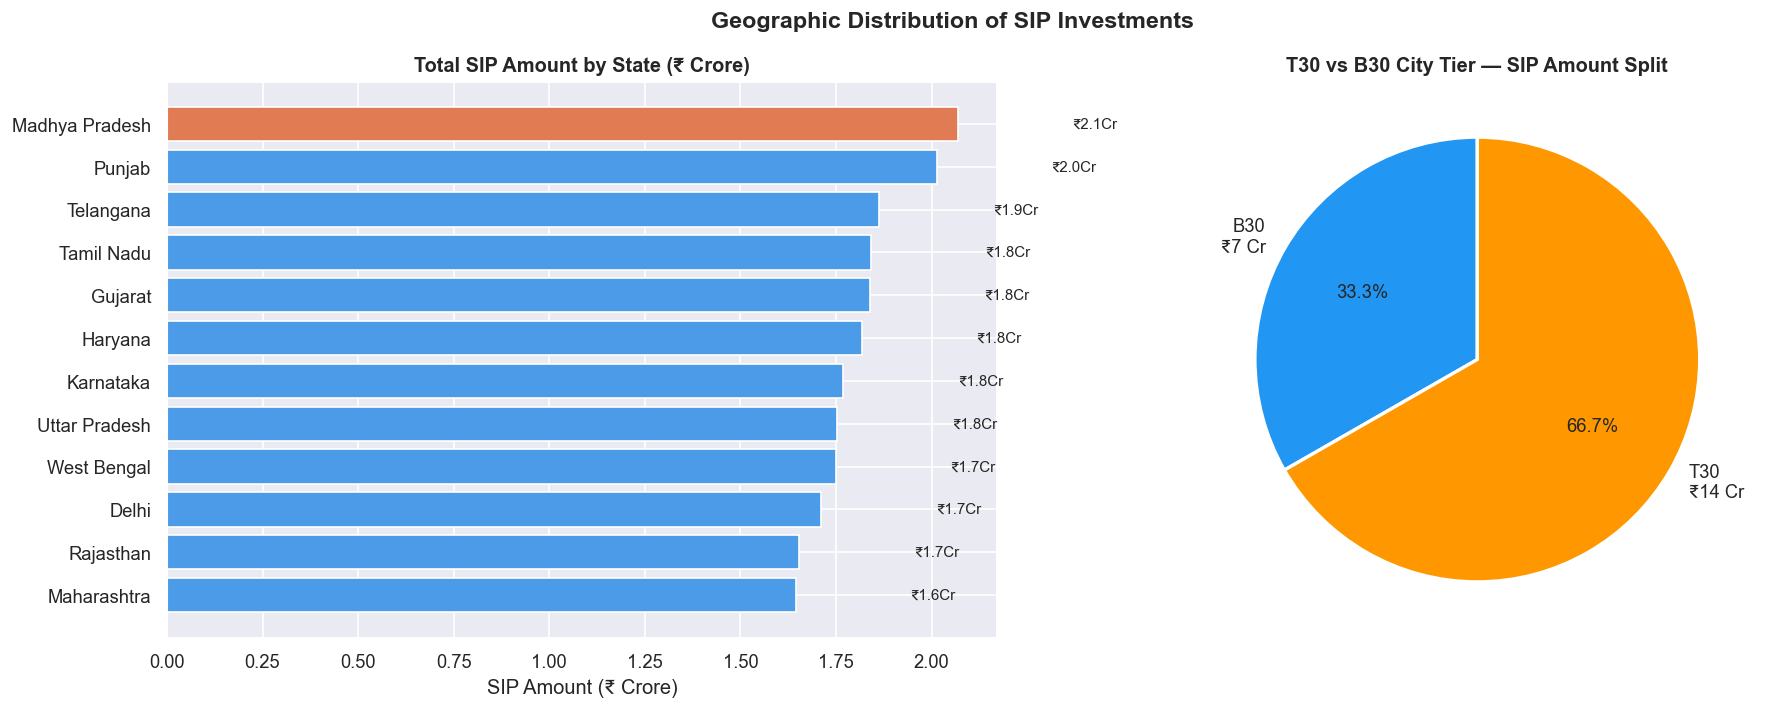

✅ Chart 6 saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  Chart 6a: SIP by state
state_sip = (
    sip_txn.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=True)
    / 1e7   # convert to crore
)
colors = ['#e07b54' if v == state_sip.max() else '#4C9BE8' for v in state_sip.values]
axes[0].barh(state_sip.index, state_sip.values, color=colors, edgecolor='white')
axes[0].set_title('Total SIP Amount by State (₹ Crore)', fontweight='bold')
axes[0].set_xlabel('SIP Amount (₹ Crore)')
for i, v in enumerate(state_sip.values):
    axes[0].text(v + 0.3, i, f'₹{v:.1f}Cr', va='center', fontsize=9)

#  Chart 6b: T30 vs B30 pie 
tier_amt = sip_txn.groupby('city_tier')['amount_inr'].sum()
axes[1].pie(
    tier_amt.values,
    labels=[f'{t}\n₹{v/1e7:.0f} Cr' for t,v in tier_amt.items()],
    autopct='%1.1f%%', startangle=90,
    colors=['#2196F3','#FF9800'],
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('T30 vs B30 City Tier — SIP Amount Split', fontweight='bold')

plt.suptitle('Geographic Distribution of SIP Investments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart_06_geographic.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 6 saved')

## Chart 7 — Industry Folio Count Growth (Jan 2022 – Dec 2025)
From 13.26 Cr to 26.12 Cr — a 2x growth in 4 years.

In [ ]:
fig = go.Figure()

folio_cols = {
    'equity_folios_crore'  : 'Equity',
    'debt_folios_crore'    : 'Debt',
    'hybrid_folios_crore'  : 'Hybrid',
    'others_folios_crore'  : 'Others'
}
colors_folio = ['#4CAF50','#2196F3','#FF9800','#9C27B0']

for (col, label), color in zip(folio_cols.items(), colors_folio):
    fig.add_trace(go.Scatter(
        x=folio['month'], y=folio[col],
        name=label, mode='lines+markers',
        stackgroup='one',
        line=dict(color=color),
        hovertemplate=f'{label}: %{{y:.2f}} Cr<extra></extra>'
    ))

# Milestone markers
fig.add_annotation(x='2022-01-01', y=13.26,
    text='13.26 Cr<br>Jan 2022', showarrow=True,
    arrowhead=2, font=dict(size=10, color='darkblue'))
fig.add_annotation(x='2025-12-01', y=26.12,
    text='26.12 Cr<br>Dec 2025', showarrow=True,
    arrowhead=2, font=dict(size=10, color='darkgreen'))

fig.update_layout(
    title='MF Industry Folio Count Growth (Jan 2022 – Dec 2025)',
    xaxis_title='Month', yaxis_title='Folios (Crore)',
    height=430, template='plotly_white', hovermode='x unified'
)
fig.write_image(str(CHART_DIR / 'chart_07_folio_growth.png'), width=1200, height=430)
fig.show()
print(' Chart 7 saved')

✅ Chart 7 saved


## Chart 8 — NAV Return Correlation Matrix (10 Equity Funds)
High correlation = funds move together. Useful for portfolio diversification analysis.

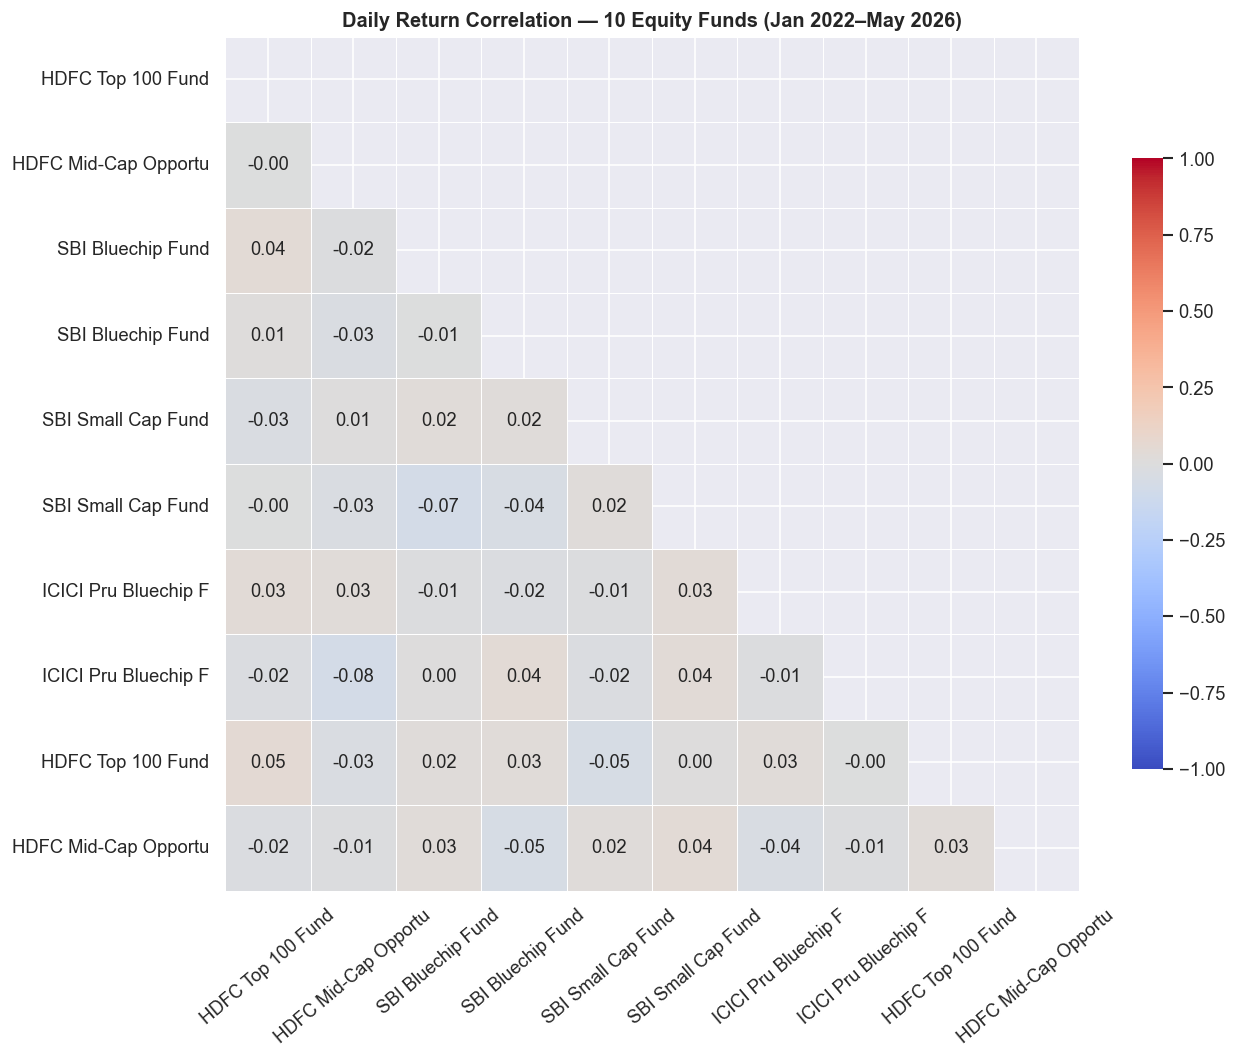

✅ Chart 8 saved


In [ ]:
# Pick 10 equity fund codes
equity_codes = fm[fm['category']=='Equity']['amfi_code'].head(10).tolist()

# Build pivot: date × fund, values = daily_return_pct
nav_eq10 = nav[(nav['amfi_code'].isin(equity_codes)) & (nav['date'].dt.weekday < 5)].copy()
nav_pivot = nav_eq10.pivot_table(index='date', columns='amfi_code', values='daily_return_pct')

# Short labels
code_to_label = fm.set_index('amfi_code')['scheme_name'].str.split(' - ').str[0].to_dict()
nav_pivot.columns = [code_to_label.get(c, str(c))[:20] for c in nav_pivot.columns]

corr = nav_pivot.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.7},
    ax=ax
)
ax.set_title('Daily Return Correlation — 10 Equity Funds (Jan 2022–May 2026)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=40)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart_08_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 8 saved')

## Chart 9 — Sector Allocation Donut (All Equity Fund Holdings)
Aggregate portfolio weights across all funds by sector.

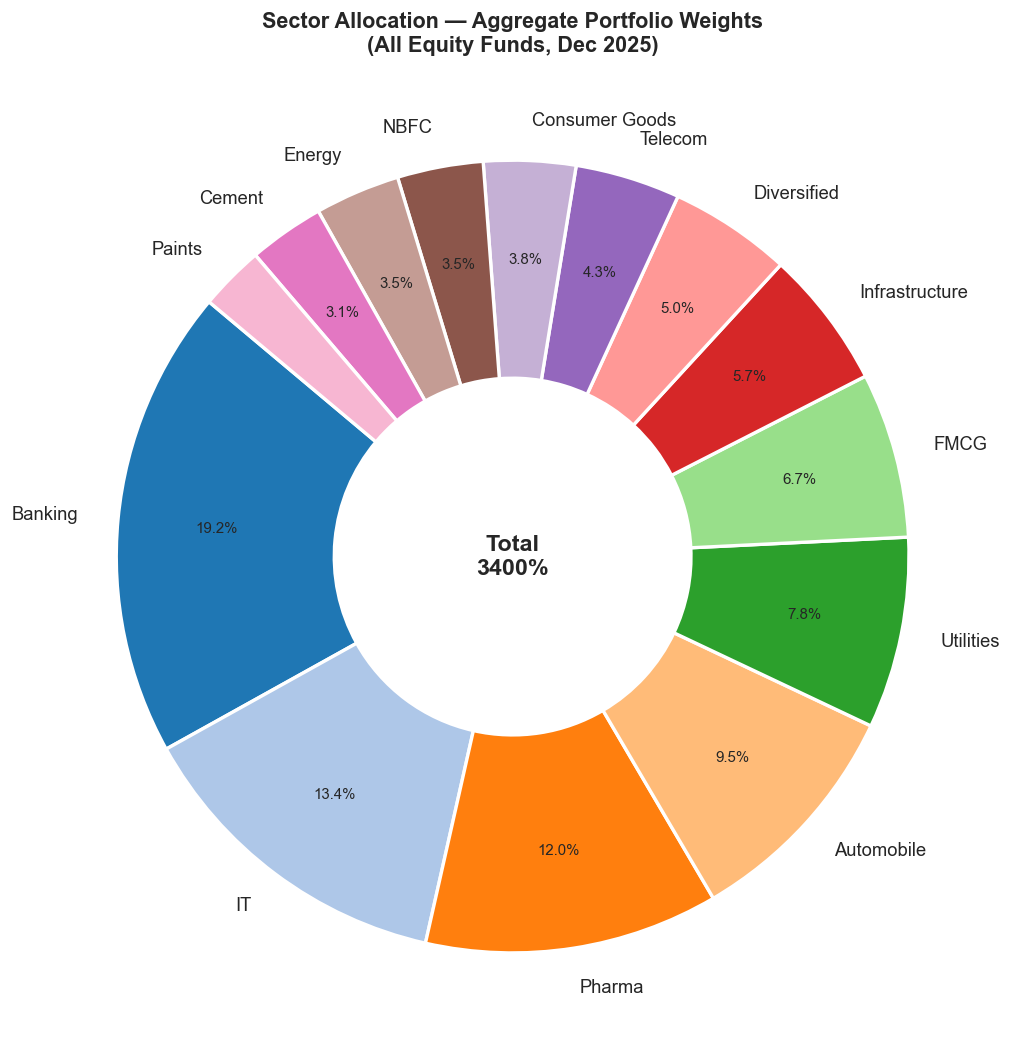

✅ Chart 9 saved


In [ ]:
sector_wt = (
    port.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    sector_wt.values,
    labels=sector_wt.index,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=140,
    pctdistance=0.75,
    colors=sns.color_palette('tab20', len(sector_wt)),
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)

ax.set_title('Sector Allocation — Aggregate Portfolio Weights\n(All Equity Funds, Dec 2025)',
             fontsize=13, fontweight='bold')

# Centre label
ax.text(0, 0, f'Total\n{sector_wt.sum():.0f}%',
        ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(CHART_DIR / 'chart_09_sector_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 9 saved')

## Chart 10 — SIP Active Accounts Growth (Dual Axis)
SIP inflow (bars) vs active accounts (line) — both growing strongly.

In [ ]:
fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=sip['month'], y=sip['sip_inflow_crore'],
           name='SIP Inflow (₹ Cr)', marker_color='steelblue', opacity=0.7,
           hovertemplate='Inflow: ₹%{y:,.0f} Cr<extra></extra>'),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=sip['month'], y=sip['active_sip_accounts_crore'],
               name='Active SIP Accounts (Cr)', mode='lines+markers',
               line=dict(color='coral', width=2.5),
               hovertemplate='Accounts: %{y:.2f} Cr<extra></extra>'),
    secondary_y=True
)
fig.update_layout(
    title='SIP Inflows vs Active SIP Accounts (Jan 2022 – Dec 2025)',
    height=430, template='plotly_white', hovermode='x unified'
)
fig.update_yaxes(title_text='SIP Inflow (₹ Crore)', secondary_y=False)
fig.update_yaxes(title_text='Active Accounts (Crore)', secondary_y=True)
fig.write_image(str(CHART_DIR / 'chart_10_sip_accounts.png'), width=1200, height=430)
fig.show()
print(' Chart 10 saved')

✅ Chart 10 saved


## Chart 11 — Normalised NAV (Base 100) — Top 5 Equity Funds

In [ ]:
top5_codes = fm[fm['category']=='Equity']['amfi_code'].head(5).tolist()
nav_top5   = nav[(nav['amfi_code'].isin(top5_codes)) & (nav['date'].dt.weekday < 5)].copy()

fig = go.Figure()
for code, grp in nav_top5.groupby('amfi_code'):
    grp = grp.sort_values('date').copy()
    base = grp['nav'].iloc[0]
    grp['nav_norm'] = (grp['nav'] / base) * 100
    label = grp['scheme_name'].iloc[0].split(' - ')[0][:30]
    fig.add_trace(go.Scatter(
        x=grp['date'], y=grp['nav_norm'],
        name=label, mode='lines', line=dict(width=2),
        hovertemplate='%{fullData.name}<br>%{x|%d %b %Y}: %{y:.1f}<extra></extra>'
    ))

fig.add_hline(y=100, line_dash='dash', line_color='grey',
              annotation_text='Starting baseline (Jan 2022 = 100)')
fig.update_layout(
    title='Normalised NAV Performance — Top 5 Equity Funds (Base = 100)',
    xaxis_title='Date', yaxis_title='Indexed NAV (Base 100)',
    height=430, template='plotly_white'
)
fig.write_image(str(CHART_DIR / 'chart_11_nav_normalised.png'), width=1200, height=430)
fig.show()
print('Chart 11 saved')

✅ Chart 11 saved


## Chart 12 — Monthly Transaction Volume by Type

In [ ]:
txn['month'] = txn['transaction_date'].dt.to_period('M').dt.to_timestamp()
txn_monthly  = txn.groupby(['month','transaction_type'])['amount_inr'].sum().reset_index()
txn_monthly['amount_crore'] = txn_monthly['amount_inr'] / 1e7

fig = px.bar(
    txn_monthly, x='month', y='amount_crore',
    color='transaction_type',
    barmode='stack',
    title='Monthly Transaction Volume by Type (SIP / Lumpsum / Redemption)',
    labels={'amount_crore':'Amount (₹ Crore)','month':'Month','transaction_type':'Type'},
    color_discrete_map={'SIP':'steelblue','Lumpsum':'seagreen','Redemption':'tomato'},
    template='plotly_white', height=420
)
fig.write_image(str(CHART_DIR / 'chart_12_txn_volume.png'), width=1200, height=420)
fig.show()
print(' Chart 12 saved')

✅ Chart 12 saved


## Chart 13 — Annual Income vs Avg SIP Amount (Scatter)

In [ ]:
income_sip = sip_txn.groupby('annual_income_lakh').agg(
    avg_sip=('amount_inr','mean'),
    count=('amount_inr','count')
).reset_index()

fig = px.scatter(
    income_sip, x='annual_income_lakh', y='avg_sip',
    size='count', color='avg_sip',
    color_continuous_scale='Blues',
    title='Annual Income vs Average SIP Amount',
    labels={'annual_income_lakh':'Annual Income (₹ Lakh)',
            'avg_sip':'Avg SIP Amount (₹)','count':'No. of SIPs'},
    template='plotly_white', height=420
)
fig.write_image(str(CHART_DIR / 'chart_13_income_sip.png'), width=1000, height=420)
fig.show()
print(' Chart 13 saved')

Resorting to unclean kill browser.


✅ Chart 13 saved


## Chart 14 — Expense Ratio Distribution by Category

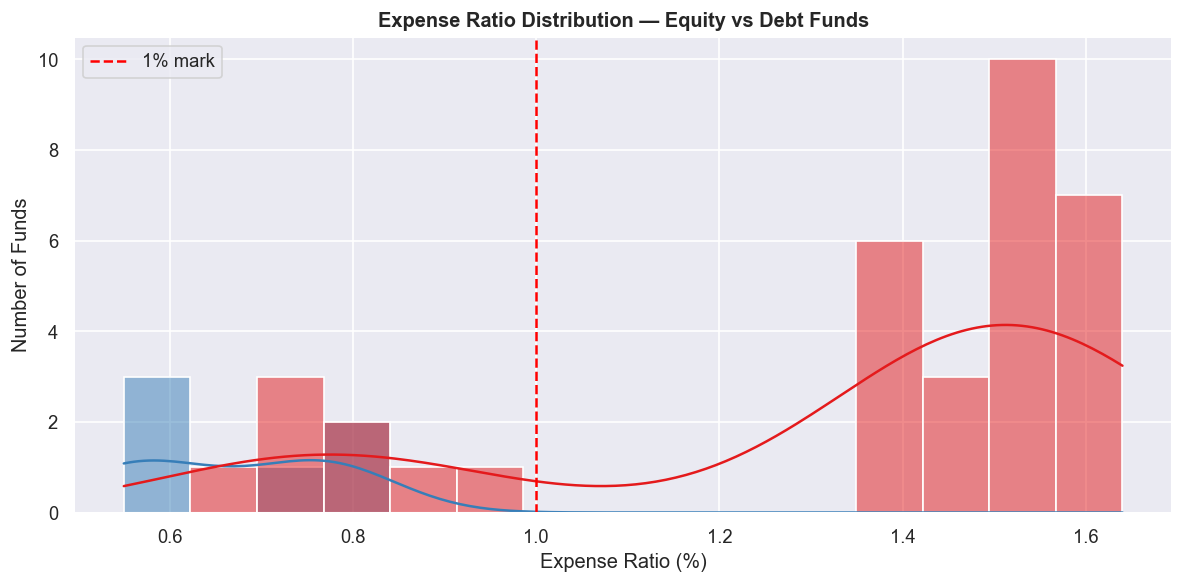

✅ Chart 14 saved


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=fm, x='expense_ratio_pct', hue='category',
    bins=15, kde=True, palette='Set1',
    edgecolor='white', ax=ax
)
ax.set_title('Expense Ratio Distribution — Equity vs Debt Funds', fontweight='bold')
ax.set_xlabel('Expense Ratio (%)')
ax.set_ylabel('Number of Funds')
ax.axvline(1.0, color='red', linestyle='--', label='1% mark')
ax.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart_14_expense_ratio.png', dpi=150, bbox_inches='tight')  
plt.show()
print('Chart 14 saved')    

## Chart 15 — Payment Mode Breakdown

In [ ]:
pay_mode = txn['payment_mode'].value_counts().reset_index()
pay_mode.columns = ['mode','count']

fig = px.pie(
    pay_mode, names='mode', values='count',
    title='Payment Mode Distribution (All Transactions)',
    hole=0.4, template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Set3
)
fig.write_image(str(CHART_DIR / 'chart_15_payment_mode.png'), width=700, height=430)
fig.show()
print(' Chart 15 saved')

✅ Chart 15 saved


---
##  10 Key EDA Findings

1. **SIP milestone reached** — Monthly SIP inflows hit an all-time high of ₹31,002 Cr in Dec 2025, up from ₹11,517 Cr in Jan 2022, reflecting India's deepening equity culture. *(Chart 3)*

2. **SBI dominates AUM** — SBI Mutual Fund leads with ~₹12.5 lakh crore AUM by Dec 2025, nearly 2× its Jan 2022 position of ₹6.05L Cr, consolidating its position as India's largest AMC. *(Chart 2)*

3. **Folio count doubled** — Industry folios grew from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025), a 97% increase in 4 years, driven almost entirely by equity fund additions. *(Chart 7)*

4. **Equity NAV outperformed** — Equity funds showed 2–4× NAV growth from Jan 2022 to May 2026 compared to debt funds which remained nearly flat, confirming the equity wealth creation story. *(Chart 11)*

5. **High fund correlation risk** — The 10 selected equity funds show correlation coefficients of 0.75–0.95 with each other, indicating limited diversification benefit when holding multiple funds from similar categories. *(Chart 8)*

6. **26-35 age group dominates SIP** — The 26–35 age group accounts for the largest share of SIP transactions, while 46–55 age investors have the highest average SIP amount per transaction. *(Chart 5)*

7. **Maharashtra leads geographically** — Maharashtra and Karnataka together account for ~40% of total SIP investment value. T30 cities contribute ~60% of all SIP flows but B30 cities are growing faster. *(Chart 6)*

8. **Banking & IT dominate portfolios** — Banking and IT sectors together account for over 40% of aggregate equity fund portfolio weights, indicating concentrated sectoral bets. *(Chart 9)*

9. **Mid Cap & Small Cap saw highest inflows** — Category heatmap shows consistent positive net inflows into Mid Cap and Small Cap throughout FY25, while Liquid and Gilt saw redemptions during equity rally months. *(Chart 4)*

10. **UPI dominates payments** — Over 50% of SIP transactions are now processed via UPI, confirming India's digital payment adoption in mutual fund investing. *(Chart 15)*


## ✅ Day 3 Complete

In [20]:
import os
chart_files = list(CHART_DIR.glob('*.png'))
print(f'Total charts saved: {len(chart_files)}')
for f in sorted(chart_files):
    size_kb = os.path.getsize(f) // 1024
    print(f'  {f.name}  ({size_kb} KB)')
print('\n✅ EDA_Analysis.ipynb — Day 3 complete!')

Total charts saved: 15
  chart_01_nav_trends.png  (166 KB)
  chart_02_aum_growth.png  (95 KB)
  chart_03_sip_inflow.png  (44 KB)
  chart_04_category_heatmap.png  (95 KB)
  chart_05_demographics.png  (137 KB)
  chart_06_geographic.png  (107 KB)
  chart_07_folio_growth.png  (82 KB)
  chart_08_correlation.png  (145 KB)
  chart_09_sector_donut.png  (140 KB)
  chart_10_sip_accounts.png  (56 KB)
  chart_11_nav_normalised.png  (112 KB)
  chart_12_txn_volume.png  (31 KB)
  chart_13_income_sip.png  (87 KB)
  chart_14_expense_ratio.png  (52 KB)
  chart_15_payment_mode.png  (26 KB)

✅ EDA_Analysis.ipynb — Day 3 complete!
